In [30]:
#%pip install git+https://github.com/devalab/molgpt.git

Loading ChEMBL reference...
ChEMBL reference: 735
Encoding reference...
Valid reference fps: 735
Loading ZINC...
ZINC candidates: 100000
Encoding ZINC...
Valid ZINC fps: 100000
Scoring ZINC...
ZINC scored: 100000
Loading MolGPT...
MolGPT candidates loaded: 188
Scoring MolGPT...
MolGPT valid non-trivial: 125
ZINC hits >0.40:   891
MolGPT hits >0.40: 101

─── ZINC ───────────────────────────────
Total scored:      100000
Hits >0.40:        891
Hits >0.60:        9
Lipinski pass:     857
PAINS clean:       868
Clean candidates:  834
Mean tanimoto:     0.225
Mean QED (hits):   0.728

─── MolGPT ───────────────────────────────
Total scored:      125
Hits >0.40:        101
Hits >0.60:        70
Lipinski pass:     101
PAINS clean:       99
Clean candidates:  99
Mean tanimoto:     0.659
Mean QED (hits):   0.557


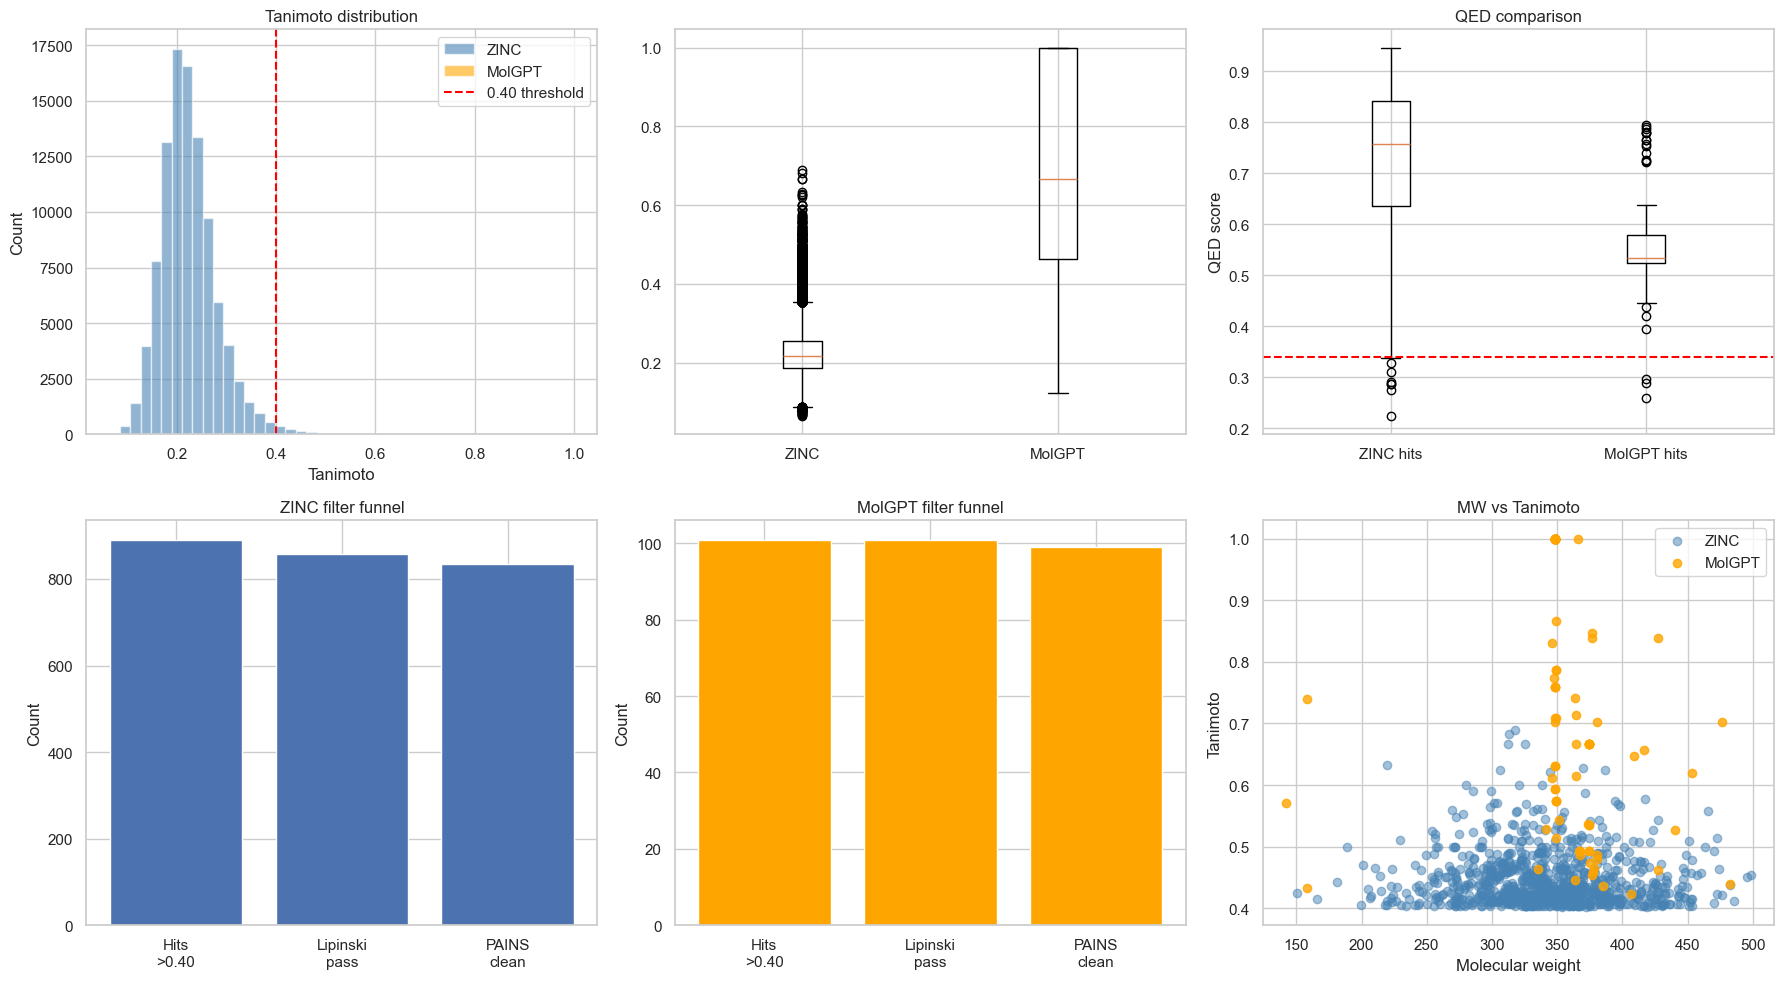

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit.DataStructs import BulkTanimotoSimilarity
from concurrent.futures import ThreadPoolExecutor
from chembl_webresource_client.new_client import new_client

# Step 1: Load ChEMBL reference (actives against HMG-CoA reductase with IC50 data)
print("Loading ChEMBL reference...")
activity      = new_client.activity
acts          = activity.filter(
                    target_chembl_id="CHEMBL1781",
                    standard_type="IC50"
                ).only("canonical_smiles")
chembl_smiles = [a["canonical_smiles"] for a in acts if a["canonical_smiles"]]
print(f"ChEMBL reference: {len(chembl_smiles)}")

# Step 2: Fingerprint generator (created once) 
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def encode(smi, min_atoms=0):
    try:
        mol = Chem.MolFromSmiles(str(smi).strip())
        if mol is None: return None
        if mol.GetNumAtoms() < min_atoms: return None
        return gen.GetFingerprint(mol)
    except:
        return None

# Step 3: Encode reference in parallel (using all CPU cores) 
print("Encoding reference...")
with ThreadPoolExecutor() as ex:
    ref_fps_raw = list(ex.map(encode, chembl_smiles))
ref_fps = [fp for fp in ref_fps_raw if fp is not None]
print(f"Valid reference fps: {len(ref_fps)}")

# Step 4: Load ZINC candidates 
print("Loading ZINC...")
url         = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
df_zinc     = pd.read_csv(url)
zinc_smiles = df_zinc["smiles"].tolist()[:100000]
print(f"ZINC candidates: {len(zinc_smiles)}")

# Step 5: Encode ZINC in parallel 
print("Encoding ZINC...")
with ThreadPoolExecutor() as ex:
    zinc_fps_raw = list(ex.map(encode, zinc_smiles))
zinc_fps = [(smi, fp) for smi, fp in zip(zinc_smiles, zinc_fps_raw) if fp is not None]
print(f"Valid ZINC fps: {len(zinc_fps)}")

# Step 6: Score ZINC (BulkTanimoto — fast C++ call)
print("Scoring ZINC...")
zinc_results = [
    {"smiles": smi, "tanimoto": max(BulkTanimotoSimilarity(fp, ref_fps)), "source": "ZINC"}
    for smi, fp in zinc_fps
]
df_zinc_scored = pd.DataFrame(zinc_results)
print(f"ZINC scored: {len(df_zinc_scored)}")

# Step 7: Load MolGPT candidates (10,000 generation run)
print("Loading MolGPT...")
path       = "/Users/girishkrishna/Documents/MSSE_Du/277B Machine Learning/Project_Code/Evidence-Aware-Validation-of-AI-Generated-Drug-Candidates-Using-PPI-Networks/molgpt/generated_statins_10k.csv"
df_gen     = pd.read_csv(path)
gen_smiles = df_gen["smiles"].tolist()
print(f"MolGPT candidates loaded: {len(gen_smiles)}")

# Step 8: Encode + Score MolGPT 
print("Scoring MolGPT...")
molgpt_results = []
for smi in gen_smiles:
    fp = encode(smi, min_atoms=10)
    if fp is None: continue
    scores = BulkTanimotoSimilarity(fp, ref_fps)
    molgpt_results.append({"smiles": smi, "tanimoto": max(scores), "source": "MolGPT"})

df_molgpt_scored = pd.DataFrame(molgpt_results)
print(f"MolGPT valid non-trivial: {len(df_molgpt_scored)}")

# Step 9: Filter hits 
zinc_hits   = df_zinc_scored[df_zinc_scored["tanimoto"]     > 0.40].copy()
molgpt_hits = df_molgpt_scored[df_molgpt_scored["tanimoto"] > 0.40].copy()
print(f"ZINC hits >0.40:   {len(zinc_hits)}")
print(f"MolGPT hits >0.40: {len(molgpt_hits)}")

# Step 10: Descriptors on hits only 
def get_descriptors(smi):
    mol = Chem.MolFromSmiles(str(smi).strip())
    if mol is None: return {}
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {"mw": round(mw,2), "logp": round(logp,2),
            "hbd": hbd, "hba": hba,
            "qed": round(qed,3), "violations": viol}

def has_pains(smi):
    params = FilterCatalogParams()
    params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
    catalog = FilterCatalog(params)
    mol = Chem.MolFromSmiles(str(smi).strip())
    if mol is None: return True
    return catalog.GetFirstMatch(mol) is not None

# build PAINS catalog once
pains_params = FilterCatalogParams()
pains_params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(pains_params)

def has_pains_fast(smi):
    mol = Chem.MolFromSmiles(str(smi).strip())
    if mol is None: return True
    return pains_catalog.GetFirstMatch(mol) is not None

for df in [zinc_hits, molgpt_hits]:
    desc           = df["smiles"].apply(get_descriptors).apply(pd.Series)
    df[desc.columns] = desc.values
    df["pains"]    = df["smiles"].apply(has_pains_fast)

# Step 11: Summary 
def summary(name, df_all, df_hits):
    clean = ((df_hits["violations"] == 0) & (~df_hits["pains"])).sum()
    print(f"\n─── {name} ───────────────────────────────")
    print(f"Total scored:      {len(df_all)}")
    print(f"Hits >0.40:        {len(df_hits)}")
    print(f"Hits >0.60:        {(df_all['tanimoto'] > 0.60).sum()}")
    print(f"Lipinski pass:     {(df_hits['violations'] == 0).sum()}")
    print(f"PAINS clean:       {(~df_hits['pains']).sum()}")
    print(f"Clean candidates:  {clean}")
    print(f"Mean tanimoto:     {df_all['tanimoto'].mean():.3f}")
    if len(df_hits) > 0:
        print(f"Mean QED (hits):   {df_hits['qed'].mean():.3f}")

summary("ZINC",   df_zinc_scored,   zinc_hits)
summary("MolGPT", df_molgpt_scored, molgpt_hits)

# Step 12: Visualisations 
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 — Tanimoto histogram
axes[0,0].hist(df_zinc_scored["tanimoto"],   bins=30, alpha=0.6, label="ZINC",   color="steelblue")
axes[0,0].hist(df_molgpt_scored["tanimoto"], bins=10, alpha=0.6, label="MolGPT", color="orange")
axes[0,0].axvline(0.40, color="red", linestyle="--", label="0.40 threshold")
axes[0,0].set(title="Tanimoto distribution", xlabel="Tanimoto", ylabel="Count")
axes[0,0].legend()

# Plot 2
axes[0,1].boxplot(
    [df_zinc_scored["tanimoto"].tolist(),
     df_molgpt_scored["tanimoto"].tolist()],
    tick_labels=["ZINC", "MolGPT"]
)

# Plot 3
axes[0,2].boxplot(
    [zinc_hits["qed"].tolist(), molgpt_hits["qed"].tolist()],
    tick_labels=["ZINC hits", "MolGPT hits"]
)
axes[0,2].axhline(0.34, color="red", linestyle="--")
axes[0,2].set(title="QED comparison", ylabel="QED score")

# Plot 4 — ZINC filter funnel
zinc_clean = ((zinc_hits["violations"] == 0) & (~zinc_hits["pains"])).sum()
axes[1,0].bar(
    ["Hits\n>0.40", "Lipinski\npass", "PAINS\nclean"],
    [len(zinc_hits), (zinc_hits["violations"]==0).sum(), zinc_clean]
)
axes[1,0].set(title="ZINC filter funnel", ylabel="Count")

# Plot 5 — MolGPT filter funnel
molgpt_clean = ((molgpt_hits["violations"] == 0) & (~molgpt_hits["pains"])).sum()
axes[1,1].bar(
    ["Hits\n>0.40", "Lipinski\npass", "PAINS\nclean"],
    [len(molgpt_hits), (molgpt_hits["violations"]==0).sum(), molgpt_clean],
    color="orange"
)
axes[1,1].set(title="MolGPT filter funnel", ylabel="Count")

# Plot 6 — MW vs Tanimoto scatter
if len(zinc_hits) > 0:
    axes[1,2].scatter(zinc_hits["mw"],   zinc_hits["tanimoto"],
                      alpha=0.5, label="ZINC",   color="steelblue")
if len(molgpt_hits) > 0:
    axes[1,2].scatter(molgpt_hits["mw"], molgpt_hits["tanimoto"],
                      alpha=0.8, label="MolGPT", color="orange")
axes[1,2].set(title="MW vs Tanimoto", xlabel="Molecular weight", ylabel="Tanimoto")
axes[1,2].legend()

plt.tight_layout()
plt.show()